In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
cc = pd.read_csv('Datasets/cc_data.csv',parse_dates=['trans_date_trans_time'])
cc.head(5)

/var/folders/xp/cg6z3x6d397bxzxj108l1mcw0000gn/T/ipykernel_16424/1327498981.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cc = pd.read_csv('Datasets/cc_data.csv',parse_dates=['trans_date_trans_time'])


,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,151888,2019-03-23 03:06:00,3586008444788260,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,...,47.4974,-122.0107,50489,Osteopath,29-02-1984,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.352172,-121.644080,0
1,1185025,2020-05-10 11:28:00,4671727014157740,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,...,40.8618,-85.6067,2304,Retail banker,25-07-1955,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.265726,-85.914050,0
2,10818,2019-01-07 13:31:00,377993105397617,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,...,44.8755,-88.1555,5548,Mining engineer,11-09-1975,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.512954,-88.693464,0
3,975275,2020-01-30 18:49:00,4710826438164840000,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,...,48.8328,-108.3961,192,Further education lecturer,04-01-1964,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.909634,-109.008657,0
4,346814,2019-06-12 03:04:00,372382441451095,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,...,41.8948,-73.9767,2471,Heritage manager,21-01-1966,8e1306b47052ac10fe48512de79edf71,1339470288,41.534838,-74.449927,0


In [6]:
loc = pd.read_csv('Datasets/location_data.csv')
loc.head(5)

,cc_num,lat,long
0,3.586010e+15,47.4974,-122.0107
1,4.671730e+15,40.8618,-85.6067
2,3.779930e+14,44.8755,-88.1555
3,4.710830e+18,48.8328,-108.3961
4,3.723820e+14,41.8948,-73.9767


In [ ]:
#What are the dimensions (number of rows and columns) of the dataset?

In [8]:
cc.shape

(389002, 23)

In [9]:
loc.shape

(979, 3)

In [ ]:
#How many unique values are there in each categorical variable?

In [10]:
categorical_cols = cc.select_dtypes(include=['object', 'category']).columns
cc_unique_counts = cc[categorical_cols].nunique()
cc_unique_counts

merchant        693
category         14
first           352
last            481
gender            2
street          979
city            890
state            51
job             492
dob             964
trans_num    389002
dtype: int64

In [ ]:
#What is the distribution of numerical variables in the dataset?

In [15]:
num_cols_cc = cc.select_dtypes(include=['int64', 'float64']).columns
cc_num_distribution = cc[num_cols_cc].describe()
cc_num_distribution

,index,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000,389002.000000,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000
mean,6.485205e+05,4.191512e+17,70.442148,48818.064295,38.533121,-90.237664,8.868084e+04,1.349251e+09,38.531683,-90.236674,0.005789
std,3.745744e+05,1.311579e+18,162.203915,26879.383224,5.074596,13.745855,3.012101e+05,1.285085e+07,5.109400,13.757311,0.075866
min,1.100000e+01,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.029798,-166.669638,0.000000
25%,3.241842e+05,1.800429e+14,9.660000,26237.000000,34.620500,-96.798000,7.430000e+02,1.338751e+09,34.719394,-96.905445,0.000000
50%,6.486485e+05,3.521417e+15,47.570000,48174.000000,39.354300,-87.476900,2.456000e+03,1.349267e+09,39.361065,-87.446843,0.000000
75%,9.735032e+05,4.642255e+15,83.077500,72011.000000,41.940400,-80.158000,2.032800e+04,1.359460e+09,41.956012,-80.253831,0.000000
max,1.296674e+06,4.992346e+18,27390.120000,99783.000000,66.693300,-67.950300,2.906700e+06,1.371817e+09,67.064277,-66.956540,1.000000


In [16]:
cc.describe()

,index,trans_date_trans_time,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,3.890020e+05,389002,3.890020e+05,389002.000000,389002.000000,389002.000000,389002.000000,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000
mean,6.485205e+05,2019-10-03 14:43:26.992457728,4.191512e+17,70.442148,48818.064295,38.533121,-90.237664,8.868084e+04,1.349251e+09,38.531683,-90.236674,0.005789
min,1.100000e+01,2019-01-01 00:06:00,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.029798,-166.669638,0.000000
25%,3.241842e+05,2019-06-03 19:15:15,1.800429e+14,9.660000,26237.000000,34.620500,-96.798000,7.430000e+02,1.338751e+09,34.719394,-96.905445,0.000000
50%,6.486485e+05,2019-10-03 12:22:00,3.521417e+15,47.570000,48174.000000,39.354300,-87.476900,2.456000e+03,1.349267e+09,39.361065,-87.446843,0.000000
75%,9.735032e+05,2020-01-29 11:37:45,4.642255e+15,83.077500,72011.000000,41.940400,-80.158000,2.032800e+04,1.359460e+09,41.956012,-80.253831,0.000000
max,1.296674e+06,2020-06-21 12:13:00,4.992346e+18,27390.120000,99783.000000,66.693300,-67.950300,2.906700e+06,1.371817e+09,67.064277,-66.956540,1.000000
std,3.745744e+05,NaN,1.311579e+18,162.203915,26879.383224,5.074596,13.745855,3.012101e+05,1.285085e+07,5.109400,13.757311,0.075866


In [17]:
loc.describe()

,cc_num,lat,long
count,9.790000e+02,979.000000,979.000000
mean,4.156463e+17,38.575058,-90.204996
std,1.302104e+18,5.115423,14.055859
min,6.041621e+10,20.027100,-165.672300
25%,1.800390e+14,34.812950,-96.735000
50%,3.524570e+15,39.401500,-87.456900
75%,4.657880e+15,41.981600,-80.169050
max,4.992350e+18,66.693300,-67.950300


In [ ]:
#Are there any missing values in the dataset? If so, how should they be handled?

In [18]:
cc.isnull().sum()

index                    0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [19]:
loc.isnull().sum()

cc_num    0
lat       0
long      0
dtype: int64

In [ ]:
#What are the summary statistics (mean, median, min, max, etc.) for numerical variables?

In [20]:
num_cols_cc = cc.select_dtypes(include=['int64', 'float64']).columns
cc_summary_stats = cc[num_cols_cc].describe()
cc_summary_stats

,index,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000,389002.000000,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000
mean,6.485205e+05,4.191512e+17,70.442148,48818.064295,38.533121,-90.237664,8.868084e+04,1.349251e+09,38.531683,-90.236674,0.005789
std,3.745744e+05,1.311579e+18,162.203915,26879.383224,5.074596,13.745855,3.012101e+05,1.285085e+07,5.109400,13.757311,0.075866
min,1.100000e+01,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.029798,-166.669638,0.000000
25%,3.241842e+05,1.800429e+14,9.660000,26237.000000,34.620500,-96.798000,7.430000e+02,1.338751e+09,34.719394,-96.905445,0.000000
50%,6.486485e+05,3.521417e+15,47.570000,48174.000000,39.354300,-87.476900,2.456000e+03,1.349267e+09,39.361065,-87.446843,0.000000
75%,9.735032e+05,4.642255e+15,83.077500,72011.000000,41.940400,-80.158000,2.032800e+04,1.359460e+09,41.956012,-80.253831,0.000000
max,1.296674e+06,4.992346e+18,27390.120000,99783.000000,66.693300,-67.950300,2.906700e+06,1.371817e+09,67.064277,-66.956540,1.000000


In [21]:
num_cols_loc = loc.select_dtypes(include=['int64', 'float64']).columns
loc_summary_stats = loc[num_cols_loc].describe()
loc_summary_stats

,cc_num,lat,long
count,9.790000e+02,979.000000,979.000000
mean,4.156463e+17,38.575058,-90.204996
std,1.302104e+18,5.115423,14.055859
min,6.041621e+10,20.027100,-165.672300
25%,1.800390e+14,34.812950,-96.735000
50%,3.524570e+15,39.401500,-87.456900
75%,4.657880e+15,41.981600,-80.169050
max,4.992350e+18,66.693300,-67.950300


In [ ]:
#Is there any correlation between numerical variables? If so, how strong is the correlation?

In [22]:
num_cols_cc = cc.select_dtypes(include=['int64', 'float64'])
cc_corr = num_cols_cc.corr()
cc_corr

,index,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
index,1.000000,0.001289,0.000779,0.000874,-0.000193,-0.001494,-0.001800,0.998976,-0.000383,-0.001475,-0.006121
cc_num,0.001289,1.000000,0.002975,0.040486,-0.059182,-0.047587,-0.009125,0.001333,-0.058560,-0.047549,-0.001280
amt,0.000779,0.002975,1.000000,0.001756,-0.000445,-0.000517,0.007271,0.000780,-0.000314,-0.000578,0.210706
zip,0.000874,0.040486,0.001756,1.000000,-0.112567,-0.910295,0.078373,0.000905,-0.111689,-0.909470,-0.001220
lat,-0.000193,-0.059182,-0.000445,-0.112567,1.000000,-0.016080,-0.155972,-0.000150,0.993599,-0.015994,0.002643
long,-0.001494,-0.047587,-0.000517,-0.910295,-0.016080,1.000000,-0.053461,-0.001608,-0.016010,0.999119,0.001376
city_pop,-0.001800,-0.009125,0.007271,0.078373,-0.155972,-0.053461,1.000000,-0.001766,-0.154767,-0.053468,0.001176
unix_time,0.998976,0.001333,0.000780,0.000905,-0.000150,-0.001608,-0.001766,1.000000,-0.000354,-0.001582,-0.006562
merch_lat,-0.000383,-0.058560,-0.000314,-0.111689,0.993599,-0.016010,-0.154767,-0.000354,1.000000,-0.015932,0.002406
merch_long,-0.001475,-0.047549,-0.000578,-0.909470,-0.015994,0.999119,-0.053468,-0.001582,-0.015932,1.000000,0.001351


In [ ]:
#How does the distribution of an amt differ across is_fraud categories?

In [23]:
cc.groupby('is_fraud')['amt'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,386750.0,67.834157,156.227752,1.00,9.6200,47.330,82.5000,27390.12
1,2252.0,518.328677,389.127281,1.18,147.8825,365.285,888.3425,1294.83


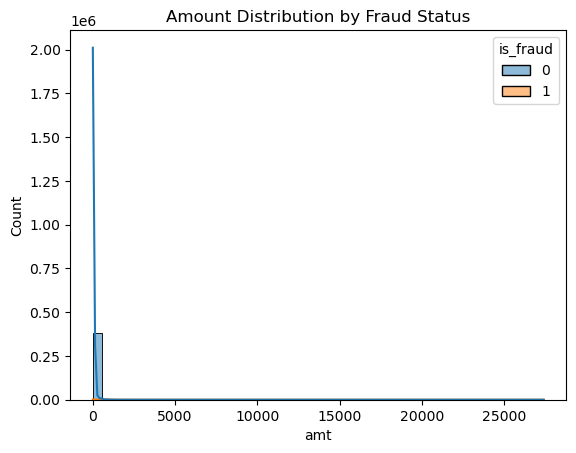

In [25]:
sns.histplot(data=cc, x='amt', hue='is_fraud', kde=True, bins=50)
plt.title("Amount Distribution by Fraud Status")
plt.show()

In [26]:
#For amt
Q1 = cc['amt'].quantile(0.25)
Q3 = cc['amt'].quantile(0.75)
IQR = Q3 - Q1

lower_bound_amt = Q1 - 1.5 * IQR
upper_bound_amt = Q3 - 1.5 * IQR

outliers_amt = cc[(cc['amt'] < lower_bound_amt) | (cc['amt'] > upper_bound_amt)]
outliers_amt.shape

(389002, 23)

<Axes: xlabel='amt'>

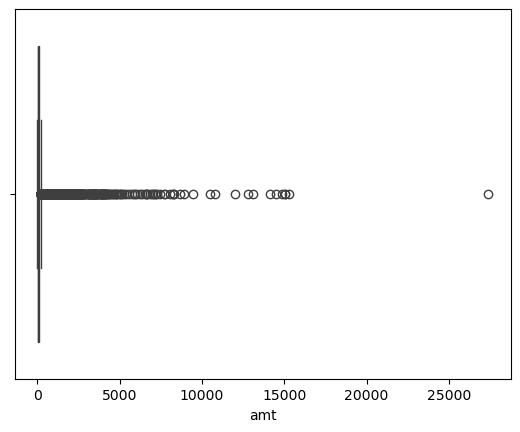

In [28]:
sns.boxplot(x=cc['amt'])

In [27]:
#For city_pop
Q1 = cc['city_pop'].quantile(0.25)
Q3 = cc['city_pop'].quantile(0.75)
IQR = Q3 - Q1

lower_bound_pop = Q1 - 1.5 * IQR
upper_bound_pop = Q3 - 1.5 * IQR

outliers_pop = cc[(cc['city_pop'] < lower_bound_pop) | (cc['city_pop'] > upper_bound_pop)]
outliers_pop.shape

(389002, 23)

<Axes: xlabel='city_pop'>

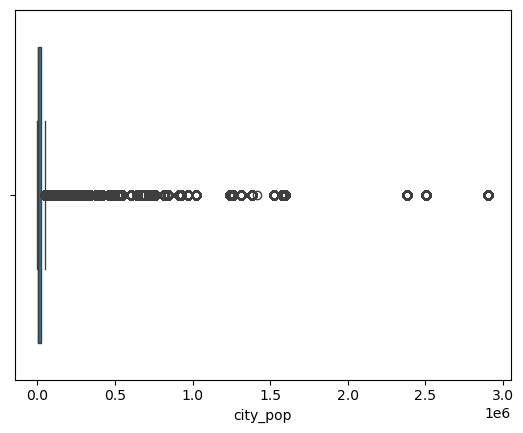

In [29]:
sns.boxplot(x=cc['city_pop'])

In [ ]:
#Are there any trends or patterns in the data over time (if applicable)?

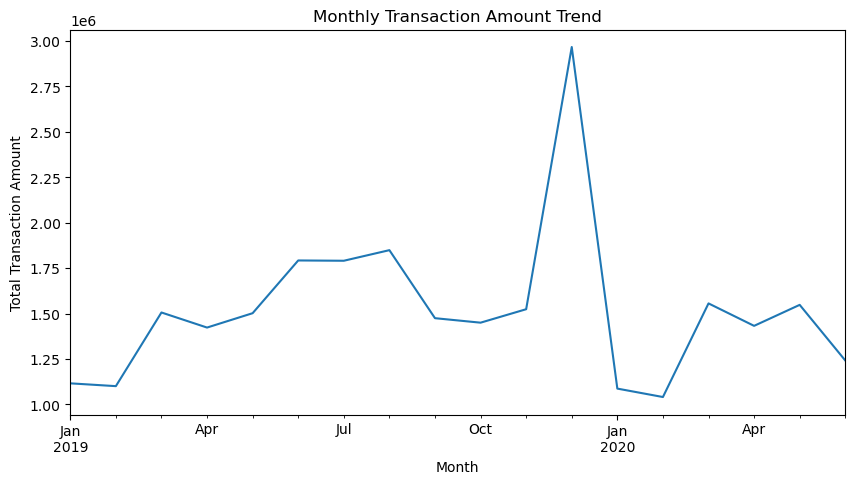

In [33]:
cc['trans_dt'] = pd.to_datetime(cc['trans_date_trans_time'], format='%d/%m/%y %H:%M')
cc['month'] = cc['trans_dt'].dt.to_period('M')
monthly_trend = cc.groupby('month')['amt'].sum()

monthly_trend.plot(kind='line', figsize=(10,5))
plt.title("Monthly Transaction Amount Trend")
plt.xlabel("Month")
plt.ylabel("Total Transaction Amount")
plt.show()

In [ ]:
#How does the target variable (if available) distribute across different categories?

In [34]:
cc.groupby('category')['is_fraud'].value_counts(normalize=True)

category        is_fraud
entertainment   0           0.997582
                1           0.002418
food_dining     0           0.998448
                1           0.001552
gas_transport   0           0.995130
                1           0.004870
grocery_net     0           0.997111
                1           0.002889
grocery_pos     0           0.985910
                1           0.014090
health_fitness  0           0.998484
                1           0.001516
home            0           0.998238
                1           0.001762
kids_pets       0           0.997818
                1           0.002182
misc_net        0           0.984983
                1           0.015017
misc_pos        0           0.996798
                1           0.003202
personal_care   0           0.997224
                1           0.002776
shopping_net    0           0.983683
                1           0.016317
shopping_pos    0           0.992774
                1           0.007226
travel       

In [ ]:
#Are there any unusual or unexpected values in the dataset that require further investigation?

In [37]:
cc['amt'].describe()

count    389002.000000
mean         70.442148
std         162.203915
min           1.000000
25%           9.660000
50%          47.570000
75%          83.077500
max       27390.120000
Name: amt, dtype: float64

In [38]:
cc['city_pop'].describe()

count    3.890020e+05
mean     8.868084e+04
std      3.012101e+05
min      2.300000e+01
25%      7.430000e+02
50%      2.456000e+03
75%      2.032800e+04
max      2.906700e+06
Name: city_pop, dtype: float64

In [39]:
cc[['lat', 'long', 'merch_lat', 'merch_long']].corr()

,lat,long,merch_lat,merch_long
lat,1.000000,-0.016080,0.993599,-0.015994
long,-0.016080,1.000000,-0.016010,0.999119
merch_lat,0.993599,-0.016010,1.000000,-0.015932
merch_long,-0.015994,0.999119,-0.015932,1.000000


In [40]:
cc['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

In [44]:
corr = cc.select_dtypes(include=['number']).corr()['is_fraud'].sort_values(ascending=False)
corr

is_fraud      1.000000
amt           0.210706
lat           0.002643
merch_lat     0.002406
long          0.001376
merch_long    0.001351
city_pop      0.001176
zip          -0.001220
cc_num       -0.001280
index        -0.006121
unix_time    -0.006562
Name: is_fraud, dtype: float64

In [ ]:
#Write an analysis report on performing exploratory data analysis (EDA) using Python
#in the context of building a fraud detection system for the financial industry.

In [ ]:
#Are there any potential data entry errors or inconsistencies in the dataset?

In [ ]:
#How does the distribution of numerical variables vary between different groups or
#segments of the dataset?

In [ ]:
#What are the top factors that influence the target variable, if applicable?